<a href="https://colab.research.google.com/github/BallFord/Iqbal-Miftahul-Fikri_2411531004_ML2526/blob/main/Praktikum%204/Latihan_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/DataSet/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

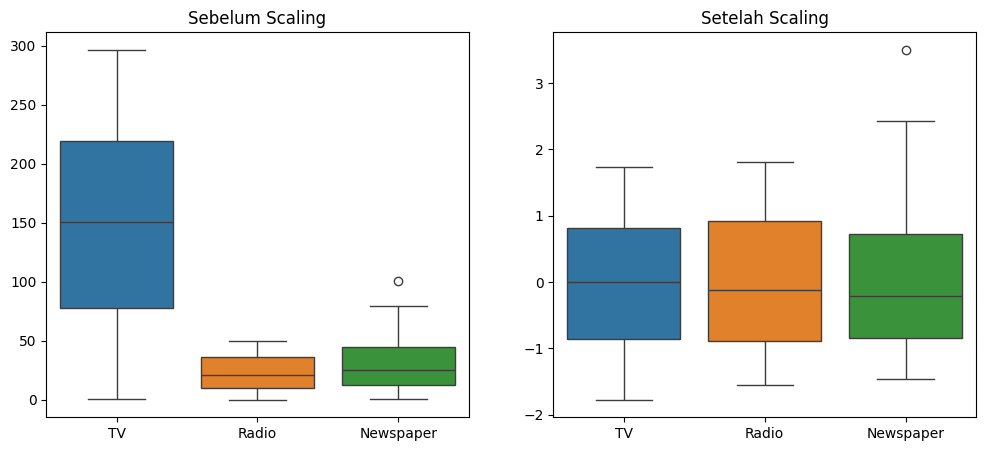

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [8]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


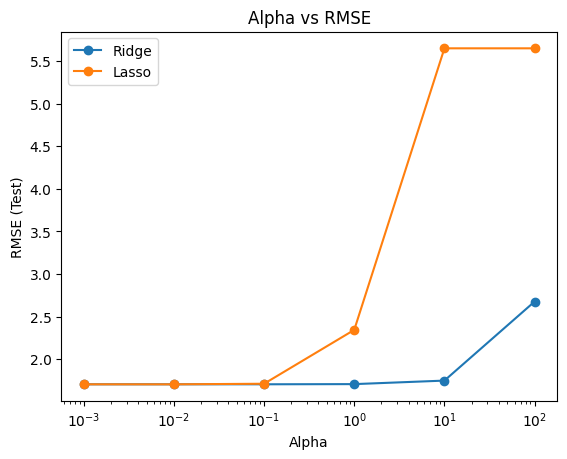

In [9]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

### **Latihan**

**Apakah Ridge Menurunkan gap RMSE Train dan Test?**

In [10]:
print("a. Evaluasi Gap RMSE (Ridge vs Linear Regression):")
gap_lr = abs(rmse_test_lr - rmse_train_lr)

gap_ridge = abs(rmse_test_ridge - rmse_train_ridge)

print(f"   Gap RMSE Linear Regression : {gap_lr:.5f}")
print(f"   Gap RMSE Ridge (alpha=1.0) : {gap_ridge:.5f}")

if gap_ridge < gap_lr:
    print("   -> Jawaban: YA, Ridge berhasil menurunkan gap RMSE.\n")
else:
    print("   -> Jawaban: TIDAK, Ridge pada percobaan ini tidak menurunkan gap RMSE.\n")

a. Evaluasi Gap RMSE (Ridge vs Linear Regression):
   Gap RMSE Linear Regression : 0.06932
   Gap RMSE Ridge (alpha=1.0) : 0.07127
   -> Jawaban: TIDAK, Ridge pada percobaan ini tidak menurunkan gap RMSE.



**Apakah Lasso Membuat Beberapa Koefisien Menjadi Nol?**

In [11]:
print("b. Evaluasi Koefisien Lasso:")
koefisien_nol = np.isclose(lasso.coef_, 0)
jumlah_nol = np.sum(koefisien_nol)

print(f"   Nilai Koefisien Lasso : {lasso.coef_}")
print(f"   Jumlah koefisien nol  : {jumlah_nol}")

if jumlah_nol > 0:
    print("   -> Jawaban: YA, Lasso berhasil membuat beberapa koefisien menjadi nol.\n")
else:
    print("   -> Jawaban: TIDAK, pada alpha=0.1 belum ada koefisien yang menjadi nol absolut.\n")

b. Evaluasi Koefisien Lasso:
   Nilai Koefisien Lasso : [4.49218143 1.42301597 0.01566227]
   Jumlah koefisien nol  : 0
   -> Jawaban: TIDAK, pada alpha=0.1 belum ada koefisien yang menjadi nol absolut.



**Pada Nilai Lambda atau Alpha Berapa RMSE Test Paling Kecil?**

In [12]:
print("c. Nilai Lambda dengan RMSE Test Terkecil:")
index_best_ridge = np.argmin(ridge_rmse)
index_best_lasso = np.argmin(lasso_rmse)

best_alpha_ridge = alphas[index_best_ridge]
best_alpha_lasso = alphas[index_best_lasso]

print(f"   RMSE test Ridge terkecil ({ridge_rmse[index_best_ridge]:.5f}) didapat pada Lambda = {best_alpha_ridge}")
print(f"   RMSE test Lasso terkecil ({lasso_rmse[index_best_lasso]:.5f}) didapat pada Lambda = {best_alpha_lasso}")
print(f"   -> Jawaban: RMSE terkecil didapat pada rentang nilai lambda yang rendah (sekitar {best_alpha_ridge} - {best_alpha_lasso}).\n")

c. Nilai Lambda dengan RMSE Test Terkecil:
   RMSE test Ridge terkecil (1.70522) didapat pada Lambda = 0.001
   RMSE test Lasso terkecil (1.70503) didapat pada Lambda = 0.01
   -> Jawaban: RMSE terkecil didapat pada rentang nilai lambda yang rendah (sekitar 0.001 - 0.01).



**Apakah lambda terlalu besar menyebabkan underfitting?**

In [13]:
rmse_lasso_terkecil = lasso_rmse[0]   # alpha = 0.001
rmse_lasso_terbesar = lasso_rmse[-1]  # alpha = 100

print(f"   RMSE Lasso dengan Lambda 0.001 : {rmse_lasso_terkecil:.5f}")
print(f"   RMSE Lasso dengan Lambda 100   : {rmse_lasso_terbesar:.5f}")

if rmse_lasso_terbesar > (rmse_lasso_terkecil * 1.5): # Jika error naik sangat signifikan (>50%)
    print("   -> Jawaban: YA, nilai lambda yang terlalu besar menyebabkan lonjakan error yang ekstrim (Underfitting).\n")
else:
    print("   -> Jawaban: TIDAK terlihat indikasi underfitting yang signifikan.\n")

   RMSE Lasso dengan Lambda 0.001 : 1.70518
   RMSE Lasso dengan Lambda 100   : 5.64822
   -> Jawaban: YA, nilai lambda yang terlalu besar menyebabkan lonjakan error yang ekstrim (Underfitting).



**Uji minimal dengan 5 nilai lambda berbeda selain nilai pada latihan praktikum.**

In [15]:
alphas_new = [0.005, 0.05, 0.5, 5, 50]

ridge_coefs = []
lasso_coefs = []

for a in alphas_new:
    r_model = Ridge(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r_model.coef_)

    l_model = Lasso(alpha=a).fit(X_train_scaled, y_train)
    lasso_coefs.append(l_model.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

**Buat grafik perubahan koefisien terhadap lambda.**

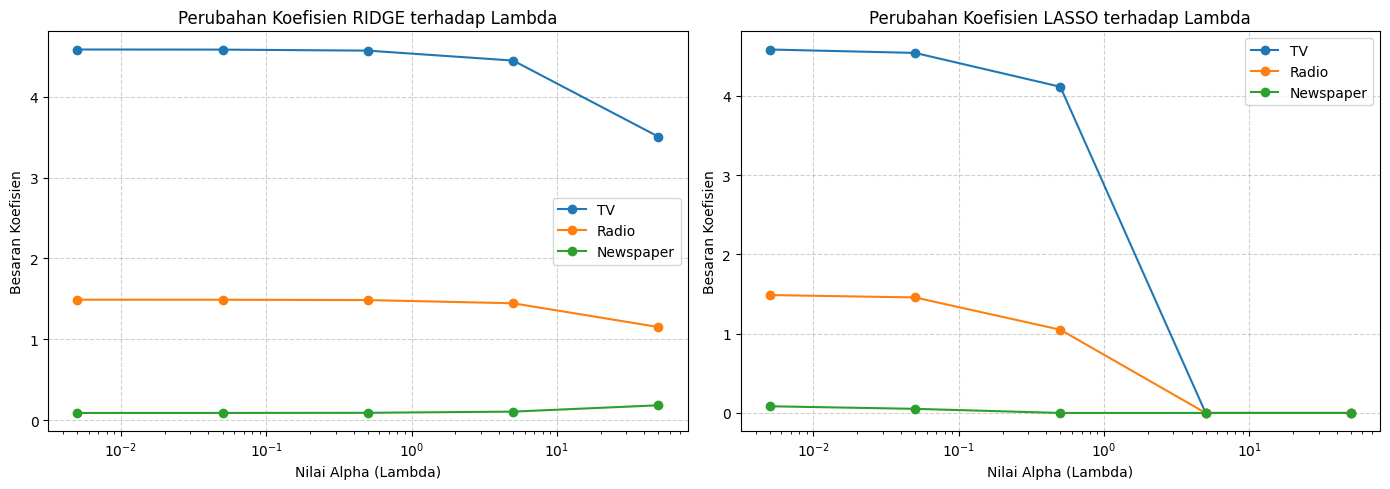

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fitur = ['TV', 'Radio', 'Newspaper']

for i in range(ridge_coefs.shape[1]):
    ax[0].plot(alphas_new, ridge_coefs[:, i], marker='o', label=fitur[i])
ax[0].set_xscale("log")
ax[0].set_xlabel("Nilai Alpha (Lambda)")
ax[0].set_ylabel("Besaran Koefisien")
ax[0].set_title("Perubahan Koefisien RIDGE terhadap Lambda")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

for i in range(lasso_coefs.shape[1]):
    ax[1].plot(alphas_new, lasso_coefs[:, i], marker='o', label=fitur[i])
ax[1].set_xscale("log")
ax[1].set_xlabel("Nilai Alpha (Lambda)")
ax[1].set_ylabel("Besaran Koefisien")
ax[1].set_title("Perubahan Koefisien LASSO terhadap Lambda")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Jelaskan perbedaan perilaku/pengaruh Ridge vs Lasso dalam konteks dataset ini.**

In [18]:
print("JAWABAN TUGAS PRAKTIKUM NO 3C\n")

penjelasan = """
Berdasarkan hasil eksperimen dan visualisasi pada dataset Advertising, berikut adalah
perbedaan perilaku antara Ridge Regression dan Lasso Regression:

1. Ridge Regression (L2 Regularization):
   - Saat nilai penalti (lambda/alpha) dinaikkan, Ridge mendorong nilai koefisien
     model menjadi lebih kecil dan mendekati nol, tetapi jarang sekali menjadikannya
     nol secara absolut.
   - Dampaknya, meskipun Ridge mengurangi dampak dari variabel-variabel prediktor
     tersebut, model akan tetap mempertahankan semua variabel (TV, Radio, Newspaper)
     di dalam perhitungannya.

2. Lasso Regression (L1 Regularization):
   - Lasso memiliki perilaku yang lebih agresif. Tidak hanya sekadar menyusutkan
     koefisien, Lasso juga dapat memaksa beberapa koefisien menjadi nol secara absolut.
   - Pada grafik percobaan, terlihat jelas bahwa koefisien fitur yang kurang relevan
     seperti Newspaper langsung ditekan jatuh ke angka nol saat lambda diperbesar.
     Ketika sebuah koefisien menjadi nol, variabel prediktor yang bersangkutan
     secara efektif dihapus dari model.
   - Karakteristik pemotongan variabel yang tidak penting ini membuat Lasso Regression
     sangat berharga untuk digunakan sebagai Feature Selection secara otomatis.
"""

print(penjelasan)

JAWABAN TUGAS PRAKTIKUM NO 3C


Berdasarkan hasil eksperimen dan visualisasi pada dataset Advertising, berikut adalah 
perbedaan perilaku antara Ridge Regression dan Lasso Regression:

1. Ridge Regression (L2 Regularization):
   - Saat nilai penalti (lambda/alpha) dinaikkan, Ridge mendorong nilai koefisien 
     model menjadi lebih kecil dan mendekati nol, tetapi jarang sekali menjadikannya 
     nol secara absolut.
   - Dampaknya, meskipun Ridge mengurangi dampak dari variabel-variabel prediktor 
     tersebut, model akan tetap mempertahankan semua variabel (TV, Radio, Newspaper) 
     di dalam perhitungannya.

2. Lasso Regression (L1 Regularization):
   - Lasso memiliki perilaku yang lebih agresif. Tidak hanya sekadar menyusutkan 
     koefisien, Lasso juga dapat memaksa beberapa koefisien menjadi nol secara absolut.
   - Pada grafik percobaan, terlihat jelas bahwa koefisien fitur yang kurang relevan 
     seperti Newspaper langsung ditekan jatuh ke angka nol saat lambda diperbesar. 